---
numbering:
  enumerator: "22.%s"
  equation:
    template: "%s"  
---

(chap_RL)=
# Reinforcement learning

Due to its increasing popularity within the Machine Learning community, we dedicate a chapter to reinforcement learning (RL). In 2019 only, more than 25 papers dedicated to RL have been submitted to (or updated on) arXiv under the **q:fin** (quantitative finance) classification. Applications to trading include @xiong2018practical and @theate2020application. Market microstructure is a focal framework (@wei2019model, @ferreira2020reinforced, @karpe2020multi).   
Moreover, an early survey of RL-based portfolios is compiled in @sato2019model (see also @zhang2020deep) and general financial applications are discussed in @kolm2019modern, @meng2019reinforcement, @charpentier2020reinforcement and @mosavi2020comprehensive. This shows again that RL has recently gained traction among the quantitative finance community.[^21-fn1]  


While RL is a framework much more than a particular algorithm, its efficient application in portfolio management is not straightforward, as we will show. For a discussion on the generalization ability of RL algorithms, we refer to @packer2018assessing and @ghosh2021generalization.

[^21-fn1]: Like neural networks, reinforcement learning methods have also been recently developed for derivatives pricing and hedging, see for instance @kolm2019dynamic and @du2020deep.


## Theoretical layout

### General framework
In this section, we introduce the core concepts of RL and follow relatively closely the notations (and layout) of
@sutton2018reinforcement, which is widely considered as a solid reference in the field, along with @bertsekas2017dynamic. One central tool in the field is called the **Markov Decision Process** (MDP, see Chapter 3 in @sutton2018reinforcement).

MDPs, like all RL frameworks, involve the interaction between an **agent** (e.g., a trader or portfolio manager) and an **environment** (e.g., a financial market). The agent performs **actions** that may alter the state of environment and gets a reward (possibly negative) for each action. This short sequence can be repeated an arbitrary number of times, as is shown in the figure below.

```{figure} images/MDP_scheme.png
:name: fig-mdpscheme
:align: center
Scheme of Markov Decision Process. R, S and A stand for reward, state and action, respectively.
```

Given initialized values for the state of the environment ($S_0$) and reward (usually $R_0=0$), the agent performs an action (e.g., invests in some assets). This generates a reward $R_1$ (e.g., returns, profits, Sharpe ratio) and also a future state of the environment ($S_1$). Based on that, the agent performs a new action and the sequence continues. When the sets of states, actions and rewards are finite, the MDP is logically called *finite*. In a financial framework, this is somewhat unrealistic and we discuss this issue later on. It nevertheless is not hard to think of simplified and discretized financial problems. For instance, the reward can be binary: win money versus lose money. In the case of only one asset, the action can also be dual: investing versus not investing. When the number of assets is sufficiently small, it is possible to set fixed proportions that lead to a reasonable number of combinations of portfolio choices, etc. 

We pursue our exposé with finite MDPs; they are the most common in the literature and their formal treatment is simpler. The relative simplicity of MDPs helps grasp the concepts that are common to other RL techniques. As is often the case with Markovian objects, the key notion is that of **transition probability**:

```{math}
:label: eq-transprob
p(s',r|s,a)=\mathbb{P}\left[S_t=s',R_t=r | S_{t-1}=s,A_{t-1}=a \right],
```

which is the probability of reaching state $s'$ and reward $r$ at time $t$, conditionally on being in state $s$ and performing action $a$ at time $t-1$. The finite sets of states and actions will be denoted with $\mathcal{S}$ and $\mathcal{A}$ henceforth.
Sometimes, this probability is averaged over the set of rewards which gives the following decomposition:

```{math}
:label: eq-transprob2
\begin{aligned}
\sum_r rp(s',r|s,a)&=\mathcal{P}_{ss'}^a \mathcal{R}_{ss'}^a, \quad \text{ where } \\
\mathcal{P}_{ss'}^a &=\mathbb{P}\left[S_t=s' | S_{t-1}=s,A_{t-1}=a \right],  \quad \text{ and } \\
 \mathcal{R}_{ss'}^a &= \mathbb{E}\left[R_t | S_{t-1}=s,S_t=s', A_{t-1}=a \right].
\end{aligned}
```

The goal of the agent is to maximize some function of the stream of rewards. This gain is usually defined as 

```{math}
:label: eq-gain
\begin{aligned}
G_t&=\sum_{k=0}^T\gamma^kR_{t+k+1} \\
&=R_{t+1} +\gamma G_{t+1},
\end{aligned}
```

i.e., it is a discounted version of the reward, where the discount factor is $\gamma \in (0,1]$. The horizon $T$ may be infinite, which is why $\gamma$ was originally introduced. Assuming the rewards are bounded, the infinite sum may diverge for $\gamma=1$. That is the case if rewards don't decrease with time and there is no reason why they should.
When $\gamma <1$ and rewards are bounded, convergence is assured. When $T$ is finite, the task is called *episodic* and, otherwise, it is said to be *continuous*.

In RL, the focal unknown to be optimized or learned is the **policy** $\pi$, which drives the actions of the agent. More precisely, $\pi(a,s)=\mathbb{P}[A_t=a|S_t=s]$, that is, $\pi$ equals the probability of taking action $a$ if the state of the environment is $s$. This means that actions are subject to randomness, just like for mixed strategies in game theory. While this may seem disappointing because an investor would want to be sure to take *the* best action, it is also a good reminder that the best way to face random outcomes may well be to randomize actions as well.

Finally, in order to try to determine the *best* policy, one key indicator is the so-called value function:

```{math}
:label: eq-RLvalue
v_\pi(s)=\mathbb{E}_\pi\left[ G_t | S_t=s \right],
```

where the time index $t$ is not very relevant and omitted in the notation of the function. The index $\pi$ under the expectation operator $\mathbb{E}[\cdot]$ simply indicates that the average is taken when the policy $\pi$ is enforced. The value function is simply equal to the average gain conditionally on the state being equal to $s$. In financial terms, this is equivalent to the average profit if the agent takes actions driven by $\pi$ when the market environment is $s$. More generally, it is also possible to condition not only on the state, but also on the action taken. We thus introduce the $q_\pi$ action-value function:

```{math}
:label: eq-RLQ
q_\pi(s,a)=\mathbb{E}_\pi\left[ G_t | S_t=s, \ A_t=a \right].
```

The $q_\pi$ function is highly important because it gives the average gain when the state and action are fixed. Hence, if the current state is known, then one obvious choice is to select the action for which $q_\pi(s,\cdot)$ is the highest. Of course, this is the best solution if the optimal value of $q_\pi$ is known, which is not always the case in practice. The value function can easily be accessed via $q_\pi$: $v_\pi(s)=\sum_a \pi(a,s)q_\pi(s,a)$.

The optimal $v_\pi$ and $q_\pi$ are straightforwardly defined as
$$v_*(s)=\underset{\pi}{\max} \, v_\pi(s), \ \forall s\in \mathcal{S}, \quad \text{ and } \quad q_*(s,a) =\underset{\pi}{\max} \, q_\pi(s,a), \ \forall (s,a)\in \mathcal{S}\times \mathcal{A}.$$

If only $v_*(s)$ is known, then the agent must span the set of actions and find those that yield the maximum value for any given state $s$.

Finding these optimal values is a very complicated task and many articles are dedicated to solving this challenge. One reason why finding the best $q_\pi(s,a)$ is difficult is because it depends on two elements ($s$ and $a$) on one side and $\pi$ on the other. Usually, for a fixed policy $\pi$, it can be time consuming to evaluate $q_\pi(s,a)$ for a given stream of actions, states and rewards. Once $q_\pi(s,a)$ is estimated, then a new policy $\pi'$ must be tested and evaluated to determine if it is better than the original one. 
Thus, this iterative search for a good policy can take long. For more details on policy improvement and value function updating, we recommend chapter 4 of @sutton2018reinforcement which is dedicated to dynamic programming.

### Q-learning

An interesting shortcut to the problem of finding $v_*(s)$ and $q_*(s,a)$ is to remove the dependence on the policy. Consequently, there is then of course no need to iteratively improve it. The central relationship that is required to do this is the so-called Bellman equation that is satisfied by $q_\pi(s,a)$. We detail its derivation below. First of all, we recall that

$$
\begin{aligned}
q_\pi(s,a) &= \mathbb{E}_\pi[G_t|S_t=s,A_t=a] \\
&= \mathbb{E}_\pi[R_{t+1}+ \gamma G_{t+1}|S_t=s,A_t=a],
\end{aligned}

$$

where the second equality stems from Equation {eq}`eq-gain`. The expression $\mathbb{E}_\pi[R_{t+1}|S_t=s,A_t=a]$ can be further decomposed. Since the expectation runs over $\pi$, we need to sum over all possible actions $a'$ and states $s'$ and resort to $\pi(a',s')$. In addition, the sum on the $s'$ and $r$ arguments of the probability $p(s',r|s,a)=\mathbb{P}\left[S_{t+1}=s',R_{t+1}=r | S_t=s,A_t=a \right]$ gives access to the distribution of the random couple $(S_{t+1},R_{t+1})$ so that in the end $\mathbb{E}_\pi[R_{t+1}|S_t=s,A_t=a]=\sum_{a', r,s'}\pi(a',s')p(s',r|s,a)  r$. A similar reasoning applies to the second portion of $q_\pi$ and:

```{math}
:label: eq-bellman
\begin{aligned}
q_\pi(s,a) &=\sum_{a',r, s'}\pi(a',s')p(s',r|s,a) \left[ r+\gamma q_\pi(s',a')\right].
\end{aligned}
```

This equation links $q_\pi(s,a)$ to the future $q_\pi(s',a')$ from the states and actions $(s',a')$ that are accessible from $(s,a)$. 

Notably, Equation {eq}`eq-bellman` is also true for the optimal action-value function $q_*=\underset{\pi}{\max} \, q_\pi(s,a)$:

```{math}
:label: eq-bellmanq
\begin{aligned}
q_*(s,a) &= \underset{a'}{\max} \sum_{r,s'}p(s',r|s,a) \left[ r+\gamma q_*(s',a')\right], \\ 
&= \mathbb{E}_{\pi^*}[r|s,a]+ \gamma \, \sum_{r,s'}p(s',r|s,a) \left(  \underset{a'}{\max}  q_*(s',a') \right)
\end{aligned}
```

because one optimal policy is one that maximizes $q_\pi(s,a)$, for a given state $s$ and over all possible actions $a$. This expression is central to a cornerstone algorithm in reinforcement learning called $Q$-learning (the formal proof of convergence is outlined in @watkins1992q). In $Q$-learning, the state-action function no longer depends on policy and is written with capital $Q$. The process is the following:

Initialize values $Q(s,a)$ for all states $s$ and actions $a$. For each episode:   
$$ (\textbf{QL}) \quad \left\{
\begin{array}{l}
\text{0. Initialize state } S_0 \text{ and for each iteration } i \text{ until the end of the episode;}   \\
\text{1. observe state } s_i;    \\
\text{2. perform action } a_i \text{(depending on } Q);   \\
\text{3. receive reward }r_{i+1} \text{ and observe state } s_{i+1};  \\
\text{4. Update } Q \text{ as follows: }
\end{array} \right.$$

```{math}
:label: eq-QLupdate
Q_{i+1}(s_i,a_i) \longleftarrow Q_i(s_i,a_i) + \eta  \left(\underbrace{r_{i+1}+\gamma \, \underset{a}{\max} \, Q_i(s_{i+1},a)}_{\text{echo of Bellman eq.}}-Q_i(s_i,a_i) \right)
```

The underlying reason this update rule works can be linked to fixed point theorems of contraction mappings. If a function $f$ satisfies $|f(x)-f(y)|< \delta |x-y|$ (Lipshitz continuity), then a fixed point $z$ satisfying $f(z)=z$ can be iteratively obtained via $z \leftarrow f(z)$. This updating rule converges to the fixed point. Equation {eq}`eq-bellmanq` can be solved using a similar principle, except that a learning rate $\eta$ slows the learning process but also technically ensures convergence under technical assumptions. 

More generally, Equation {eq}`eq-QLupdate` has a form that is widespread in reinforcement learning that is summarized in Equation (2.4) of @sutton2018reinforcement:

```{math}
:label: eq-RLeq
\text{New estimate} \leftarrow \text{Old estimate + Step size (}i.e., \text{ learning rate)} \times (\text{Target - Old estimate}),
```

where the last part can be viewed as an error term. Starting from the old estimate, the new estimate therefore goes in the 'right' (or sought) direction, modulo a discount term that makes sure that the magnitude of this direction is not too large. The update rule in Equation {eq}`eq-QLupdate` is often referred to as '*temporal difference*' learning because it is driven by the improvement yielded by estimates that are known at time $t+1$ (target) versus those known at time $t$.

One important step of the *Q*-learning sequence (**QL**) is the second one where the action $a_i$ is picked. In RL, the best algorithms combine two features: **exploitation** and **exploration**. Exploitation is when the machine uses the current information at its disposal to choose the next action. In this case, for a given state $s_i$, it chooses the action $a_i$ that maximizes the expected reward $Q_i(s_i,a_i)$. While obvious, this choice is not optimal if the current function $Q_i$ is relatively far from the *true* $Q$. Repeating the locally optimal strategy is likely to favor a limited number of actions, which will narrowly improve the accuracy of the $Q$ function.

In order to gather new information stemming from actions that have not been tested much (but that can potentially generate higher rewards), exploration is needed. This is when an action $a_i$ is chosen randomly. The most common way to combine these two concepts is called $\epsilon$-greedy exploration. The action $a_i$ is assigned according to:

```{math}
:label: eq-egreedy
a_i=\left\{ \begin{array}{c l}
\underset{a}{\text{argmax}} \ Q_i(s_i,a) & \text{ with probability } 1-\epsilon \\
\text{randomly (uniformly) over } \mathcal{A} & \text{ with probability } \epsilon
\end{array}\right. .
```

Thus, with probability $\epsilon$, the algorithm explores and with probability $1-\epsilon$, it exploits the current knowledge of the expected reward and picks the best action. Because all actions have a non-zero probability of being chosen, the policy is called "soft". Indeed, then best action has a probability of selection equal to $1-\epsilon(1-\text{card}(\mathcal{A})^{-1})$, while all other actions are picked with probability $\epsilon/\text{card}(\mathcal{A})$.

### SARSA

In $Q$-learning, the algorithm seeks to find the action-value function of the optimal policy. Thus, the policy that is followed to pick actions is different from the one that is learned (via $Q$). Such algorithms are called *off-policy*. *On-policy* algorithms seek to improve the estimation of the action-value function $q_\pi$ by continuously acting according to the policy $\pi$. One canonical example of on-policy learning is the SARSA method which requires two consecutive states and actions **SA**R**SA**. The way the quintuple $(S_t,A_t,R_{t+1}, S_{t+1}, A_{t+1})$ is processed is presented below. 

The main difference between $Q$ learning and SARSA is the update rule. In SARSA, it is given by

```{math}
:label: eq-SARSAupdate
Q_{i+1}(s_i,a_i) \longleftarrow Q_i(s_i,a_i) + \eta  \left(r_{i+1}+\gamma \, Q_i(s_{i+1},a_{i+1})-Q_i(s_i,a_i) \right)
```

The improvement comes only from the **local** point $Q_i(s_{i+1},a_{i+1})$ that is based on the new states and actions ($s_{i+1},a_{i+1}$), whereas in $Q$-learning, it comes from all possible actions of which only the best is retained $\underset{a}{\max} \, Q_i(s_{i+1},a)$.

A more robust but also more computationally demanding version of SARSA is *expected* SARSA in which the target $Q$ function is averaged over all actions: 

```{math}
:label: eq-exSARSAupdate
Q_{i+1}(s_i,a_i) \longleftarrow Q_i(s_i,a_i) + \eta  \left(r_{i+1}+\gamma \, \sum_a \pi(a,s_{i+1}) Q_i(s_{i+1},a) -Q_i(s_i,a_i) \right)
```

Expected SARSA is less volatile than SARSA because the latter is strongly impacted by the random choice of $a_{i+1}$. In expected SARSA, the average smoothes the learning process.

## The curse of dimensionality

Let us first recall that reinforcement learning is a framework that is not linked to a particular algorithm. In fact, different tools can very well co-exist in a RL task (AlphaGo combined both tree methods and neural networks, see @silver2016mastering). Nonetheless, any RL attempt will always rely on the three key concepts: the states,  actions and rewards. In factor investing, they are fairly easy to identify, though there is always room for interpretation. Actions are evidently defined by portfolio compositions. The states can be viewed as the current values that describe the economy: as a first-order approximation, it can be assumed that the feature levels fulfill this role (possibly conditioned or complemented with macro-economic data). The rewards are even more straightforward. Returns or any relevant performance metric[^21-fn2] can account for rewards. 

A major problem lies in the dimensionality of both states and actions. Assuming an absence of leverage (no negative weights), the actions take values on the simplex

```{math}
:label: eq-simplex
\mathbb{S}_N=\left\{ \mathbf{x} \in \mathbb{R}^N\left|\sum_{n=1}^Nx_n=1, \ x_n\ge 0, \ \forall n=1,\dots,N \right.\right\}
```

and assuming that all features have been uniformized, their space is $[0,1]^{NK}$. Needless to say, the dimensions of both spaces are numerically impractical. 

A simple solution to this problem is discretization: each space is divided into a small number of categories. Some authors do take this route. In @yang2018investor, the state space is discretized into three values depending on volatility, and actions are also split into three categories. @bertoluzzo2012testing, @xiong2018practical and @taghian2020learning also choose three possible actions (buy, hold, sell). In @almahdi2019constrained, the learner is expected to yield binary signals for buying or shorting. @garcia2019continuous consider a larger state space (8 elements) but restrict the action set to 3 options.[^21-fn3] In terms of the state space, all articles assume that the state of the economy is determined by prices (or returns).

One strong limitation of these approaches is the marked simplification they imply. Realistic discretizations are numerically intractable when investing in multiple assets. Indeed, splitting the unit interval in $h$ points yields $h^{NK}$ possibilities for feature values. The number of options for weight combinations is exponentially increasing with $N$. As an example: just 10 possible values for 10 features of 10 stocks yield $10^{100}$ permutations. 

The problems mentioned above are of course not restricted to portfolio construction. Many solutions have been proposed to solve Markov Decision Processes in continuous spaces. We refer for instance to Section 4 in @powell2011review for a review of early methods (outside finance). 

This curse of dimensionality is accompanied by the fundamental question of training data. Two options are conceivable: market data versus simulations. Under a given controlled generator of samples, it is hard to imagine that the algorithm will beat the solution that maximizes a given utility function. If anything, it should converge towards the static optimal solution under a stationary data generating process (see, e.g., @chaouki2020deep for trading tasks), which is by the way a very strong modelling assumption.   

This leaves market data as a preferred solution but even with large datasets, there is little chance to cover all the (actions, states) combinations mentioned above. Characteristics-based datasets have depths that run through a few decades of monthly data, which means several hundreds of time-stamps at most. This is by far too limited to allow for a reliable learning process. It is always possible to generate synthetic data (as in @yu2019model), but it is unclear that this will solidly improve the performance of the algorithm.

[^21-fn2]: e.g., Sharpe ratio which is for instance used in @moody1998performance, @bertoluzzo2012testing and @aboussalah2020continuous or drawdown-based ratios, as in @almahdi2017adaptive.

[^21-fn3]: Some recent papers consider arbitrary weights (e.g., @jiang2017deep and @yu2019model) for a limited number of assets.


## Policy gradient

### Principle

Beyond the discretization of action and state spaces, a powerful trick is **parametrization**. When $a$ and $s$ can take discrete values, action-value functions must be computed for all pairs $(a,s)$, which can be prohibitively cumbersome. An elegant way to circumvent this problem is to assume that the policy is driven by a relatively modest number of parameters. The learning process is then focused on optimizing this set of parameters $\boldsymbol{\theta}$. We then write $\pi_{\boldsymbol{\theta}}(a,s)$ for the probability of choosing action $a$ in state $s$. One intuitive way to define $\pi_{\boldsymbol{\theta}}(a,s)$ is to resort to a soft-max form:

```{math}
:label: eq-policyex
\pi_{\boldsymbol{\theta}}(a,s) = \frac{e^{\boldsymbol{\theta}'\textbf{h}(a,s)}}{\sum_{b}e^{\boldsymbol{\theta}'\textbf{h}(b,s)}},
```

where the output of function $\textbf{h}(a,s)$, which has the same dimension as $\boldsymbol{\theta}$ is called a feature vector representing the pair $(a,s)$. Typically, $\textbf{h}$ can very well be a simple neural network with two input units and an output dimension equal to the length of $\boldsymbol{\theta}$.

One desired property for $\pi_{\boldsymbol{\theta}}$ is that it be differentiable with respect to $\boldsymbol{\theta}$ so that $\boldsymbol{\theta}$ can be improved via some gradient method. The most simple and intuitive results about policy gradients are known in the case of episodic tasks (finite horizon) for which it is sought to maximize the average gain $\mathbb{E}_{\boldsymbol{\theta}}[G_t]$ where the gain is defined in Equation {eq}`eq-gain`. The expectation is computed according to a particular policy that depends on $\boldsymbol{\theta}$, this is why we use a simple subscript. One central result is the so-called policy gradient theorem which states that  

```{math}
:label: eq-PGT
\nabla \mathbb{E}_{\boldsymbol{\theta}}[G_t]=\mathbb{E}_{\boldsymbol{\theta}} \left[G_t\frac{\nabla \pi_{\boldsymbol{\theta}}}{\pi_{\boldsymbol{\theta}}} \right].
```

This result can then be used for **gradient ascent**: when seeking to maximize a quantity, the parameter change must go in the upward direction:

```{math}
:label: eq-ascent
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} + \eta \nabla \mathbb{E}_{\boldsymbol{\theta}}[G_t].
```

This simple update rule is known as the **REINFORCE** algorithm. One improvement of this simple idea is to add a baseline, and we refer to section 13.4 of @sutton2018reinforcement for a detailed account on this topic.

### Extensions

A popular extension of REINFORCE is the so-called **actor-critic** (AC) method which combines policy gradient with $Q$- or $v$-learning. The AC algorithm can be viewed as some kind of mix between policy gradient and SARSA. A central requirement is that the state-value function $v(\cdot)$ be a differentiable function of some parameter vector $\textbf{w}$ (it is often taken to be a neural network). The update rule is then

```{math}
:label: eq-ascentAC
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} + \eta \left(R_{t+1}+\gamma v(S_{t+1},\textbf{w})-v(S_t,\textbf{w}) \right)\frac{\nabla \pi_{\boldsymbol{\theta}}}{\pi_{\boldsymbol{\theta}}},
```

but the trick is that the vector $\textbf{w}$ must also be updated. The actor is the policy side which is what drives decision making. The critic side is the value function that evaluates the actor's performance. As learning progresses (each time both sets of parameters are updated), both sides improve. The exact algorithmic formulation is a bit long and we refer to Section 13.5 in @sutton2018reinforcement for the precise sequence of steps of AC.

Another interesting application of parametric policies is outlined in @aboussalah2020continuous. In their article, the authors define a trading policy that is based on a recurrent neural network. Thus, the parameter $\boldsymbol{\theta}$ in this case encompasses all weights and biases in the network. 

Another favorable feature of parametric policies is that they are compatible with continuous sets of actions. Beyond the form {eq}`eq-policyex`, there are other ways to shape $\pi_{\boldsymbol{\theta}}$. If $\mathcal{A}$ is a subset of $\mathbb{R}$, and $f_{\boldsymbol{\Omega}}$ is a density function with parameters $\boldsymbol{\Omega}$, then a candidate form for $\pi_{\boldsymbol{\theta}}$ is

```{math}
:label: eq-parpol
\pi_{\boldsymbol{\theta}} = f_{\boldsymbol{\Omega}(s,\boldsymbol{\theta})}(a),
```

in which the parameters $\boldsymbol{\Omega}$ are in turn functions of the states and of the underlying (second order) parameters $\boldsymbol{\theta}$. 

While the Gaussian distribution (see section 13.7 in @sutton2018reinforcement) is often a preferred choice, they would require some processing to lie inside the unit interval. One easy way to obtain such values is to apply the normal cumulative distribution function to the output. In @wang2019continuous, the multivariate Gaussian policy is theoretically explored, but it assumes no constraint on weights.

Some natural parametric distributions emerge as alternatives. If only one asset is traded, then the Bernoulli distribution can be used to determine whether or not to buy the asset. If a riskless asset is available, the beta distribution offers more flexibility because the values for the proportion invested in the risky asset span the whole interval; the remainder can be invested into the safe asset. When many assets are traded, things become more complicated because of the budget constraint. One ideal candidate is the Dirichlet distribution because it is defined on a simplex (see Equation {eq}`eq-simplex`):
$$f_{\boldsymbol{\alpha}}(w_1,\dots,w_n)=\frac{1}{B(\boldsymbol{\alpha})}\prod_{n=1}^Nw_n^{\alpha_n-1},$$
where $B(\boldsymbol{\alpha})$ is the multinomial beta function: 
$$B(\boldsymbol{\alpha})=\frac{\prod_{n=1}^N\Gamma(\alpha_n)}{\Gamma\left(\sum_{n=1}^N\alpha_n \right)}.$$ 

If we set $\pi=\pi_{\boldsymbol{\alpha}}=f_{\boldsymbol{\alpha}}$, the link with factors or characteristics can be coded through ${\boldsymbol{\alpha}}$ via a linear form:

$$(\textbf{F1}) \quad  \alpha_{n,t}=\theta_{0,t} + \sum_{k=1}^K \theta_{t}^{(k)}x_{t,n}^{(k)},$$

which is highly tractable, but may violate the condition that $\alpha_{n,t}>0$ for some values of $\theta_{k,t}$. Indeed, during the learning process, an update in $\boldsymbol{\theta}$ might yield values that are out of the feasible set of $\boldsymbol{\alpha}_t$. In this case, it is possible to resort to a trick that is widely used in online learning (see, e.g., section 2.3.1 in @hoi2018online). The idea is simply to find the acceptable solution that is closest to the suggestion from the algorithm. If we call $\boldsymbol{\theta}^*$ the result of an update rule from a given algorithm, then the closest feasible vector is 

$$\boldsymbol{\theta}= \underset{\textbf{z} \in \Theta(\textbf{x}_t)}{\min} ||\boldsymbol{\theta}^*-\textbf{z}||^2,$$

where $||\cdot||$ is the Euclidean norm and $\Theta(\textbf{x}_t)$ is the feasible set, that is, the set of vectors $\boldsymbol{\theta}$ such that the $\alpha_{n,t}=\theta_{0,t} + \sum_{k=1}^K \theta_{t}^{(k)}x_{t,n}^{(k)}$ are all non-negative.

A second option for the form of the policy, $\pi^2_{\boldsymbol{\theta}_t}$, is slightly more complex but remains always valid (i.e., has positive $\alpha_{n,t}$ values):

$$(\textbf{F2}) \quad  \alpha_{n,t}=\exp \left(\theta_{0,t} + \sum_{k=1}^K \theta_{t}^{(k)}x_{t,n}^{(k)}\right),$$

which is simply the exponential of the first version. With some algebra, it is possible to derive the policy gradients. The policies $\pi^j_{\boldsymbol{\theta}_t}$ are defined by the Equations $(\textbf{Fj})$ above. Let $\digamma$ denote the digamma function. Let $\textbf{1}$ denote the $\mathbb{R}^N$ vector of all ones. We have

$$
\begin{aligned}
\frac{\nabla_{\boldsymbol{\theta}_t} \pi^1_{\boldsymbol{\theta}_t}}{\pi^1_{\boldsymbol{\theta}_t}}&= \sum_{n=1}^N \left( \digamma \left( \textbf{1}'\textbf{X}_t\boldsymbol{\theta}_t \right) - \digamma(\textbf{x}_{t,n}\boldsymbol{\theta}_t) + \ln w_n \right) \textbf{x}_{t,n}' \\
\frac{\nabla_{\boldsymbol{\theta}_t} \pi^2_{\boldsymbol{\theta}_t}}{\pi^2_{\boldsymbol{\theta}_t}}&= \sum_{n=1}^N \left( \digamma \left( \textbf{1}'e^{\textbf{X}_{t}\boldsymbol{\theta}_t} \right) - \digamma(e^{\textbf{x}_{t,n}\boldsymbol{\theta}_t}) + \ln w_n \right) e^{\textbf{x}_{t,n}\boldsymbol{\theta}_t} \textbf{x}_{t,n}' 
\end{aligned}
$$

where $e^{\textbf{X}}$ is the element-wise exponential of a matrix $\textbf{X}$.

The allocation can then either be made by direct sampling, or using the mean of the distribution $(\textbf{1}'\boldsymbol{\alpha})^{-1}\boldsymbol{\alpha}$. Lastly, a technical note: Dirichlet distributions can only be used for small portfolios because the scaling constant in the density becomes numerically intractable for large values of $N$ (e.g., above 50). More details on this idea are laid out in @andre2020dirichlet.

## Simple examples

### Setup and Imports

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Building the data
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

### Q-learning with simulations

To illustrate the gist of the problems mentioned above, we propose two implementations of $Q$-learning. For simplicity, the first one is based on simulations. This helps understand the learning process in a simplified framework. We consider two assets: one risky and one riskless, with return equal to zero. The returns for the risky process follow an autoregressive model of order one (AR(1)): $r_{t+1}=a+\rho r_t+\epsilon_{t+1}$ with $|\rho|<1$ and $\epsilon$ following a standard white noise with variance $\sigma^2$. In practice, individual (monthly) returns are seldom autocorrelated, but adjusting the autocorrelation helps understand if the algorithm learns correctly (see exercise below). 

The environment consists only in observing the past return $r_t$. Since we seek to estimate the $Q$ function, we need to discretize this state variable. The simplest choice is to resort to a binary variable: equal to -1 (negative) if $r_t<0$ and to +1 (positive) if $r_t\ge 0$. The actions are summarized by the quantity invested in the risky asset. It can take 5 values: 0 (risk-free portfolio), 0.25, 0.5, 0.75 and 1 (fully invested in the risky asset). This is for instance the same choice as in @pendharkar2018trading.

Below we implement a simple Q-learning algorithm from scratch in Python. The landscape of Python libraries for RL is richer than R, with options like **Stable-Baselines3**, **RLlib**, and **Gymnasium** (formerly OpenAI Gym). However, for pedagogical purposes and to match the simplicity of the original example, we implement Q-learning directly.

In [16]:
class QLearningAgent:
    """
    A simple Q-learning agent for tabular environments.
    """
    def __init__(self, states, actions, alpha=0.1, gamma=0.7, epsilon=0.1):
        """
        Initialize the Q-learning agent.
        
        Parameters:
        -----------
        states : list
            List of possible states
        actions : list
            List of possible actions
        alpha : float
            Learning rate (eta in the equations)
        gamma : float
            Discount factor for future rewards
        epsilon : float
            Exploration rate for epsilon-greedy policy
        """
        self.states = states
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        
        # Initialize Q-table with zeros
        self.Q = {s: {a: 0.0 for a in actions} for s in states}
    
    def choose_action(self, state):
        """Choose action using epsilon-greedy policy."""
        if np.random.random() < self.epsilon:
            # Explore: random action
            return np.random.choice(self.actions)
        else:
            # Exploit: best action based on Q-values
            return max(self.actions, key=lambda a: self.Q[state][a])
    
    def update(self, state, action, reward, next_state):
        """Update Q-value using the Q-learning update rule."""
        # Q-learning update (Equation eq-QLupdate)
        best_next_q = max(self.Q[next_state].values())
        td_target = reward + self.gamma * best_next_q
        td_error = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error
    
    def train_on_data(self, data):
        """
        Train the agent on a dataset.
        
        Parameters:
        -----------
        data : pd.DataFrame
            DataFrame with columns: state, action, reward, new_state
        """
        for _, row in data.iterrows():
            self.update(row['state'], row['action'], row['reward'], row['new_state'])
    
    def get_policy(self):
        """Return the best action for each state."""
        return {s: max(self.actions, key=lambda a: self.Q[s][a]) for s in self.states}
    
    def get_q_table(self):
        """Return Q-table as a DataFrame."""
        return pd.DataFrame(self.Q).T

Now let's generate the simulated data with an AR(1) process and train our Q-learning agent.

In [17]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters for AR(1) simulation
n_sample = 10**5           # Number of samples to be generated
rho = 0.8                  # Autoregressive parameter
sd = 0.4                   # Std. dev. of noise
a = 0.06 * rho             # Scaled mean of returns

# Generate AR(1) returns
def simulate_ar1(n, rho, a, sd):
    """Simulate AR(1) process: r_{t+1} = a + rho * r_t + epsilon_{t+1}"""
    returns = np.zeros(n)
    returns[0] = a / (1 - rho)  # Start at unconditional mean
    epsilon = np.random.normal(0, sd, n)
    for t in range(1, n):
        returns[t] = a + rho * returns[t-1] + epsilon[t]
    return returns

# Generate returns
returns_sim = simulate_ar1(n_sample, rho, a, sd)

# Create dataset for Q-learning
# Random actions: 0, 0.25, 0.5, 0.75, 1.0
actions = np.round(np.random.uniform(0, 1, n_sample) * 4) / 4

data_RL = pd.DataFrame({
    'returns': returns_sim,
    'action': actions
})

# Code the state: 'neg' if return < 0, 'pos' otherwise
data_RL['new_state'] = np.where(data_RL['returns'] < 0, 'neg', 'pos')

# Reward = portfolio return = returns * action (proportion invested)
data_RL['reward'] = data_RL['returns'] * data_RL['action']

# State is the lagged new_state
data_RL['state'] = data_RL['new_state'].shift(1)

# Convert action to string for consistency
data_RL['action'] = data_RL['action'].astype(str)

# Remove first row with NaN state
data_RL = data_RL.dropna().reset_index(drop=True)

print("First rows of the RL dataset:")
data_RL.head()

First rows of the RL dataset:


,returns,action,new_state,reward,state
0,0.184694,0.75,pos,0.138521,pos
1,0.454831,0.25,pos,0.113708,pos
2,1.021077,0.75,pos,0.765807,pos
3,0.771200,0.0,pos,0.000000,pos
4,0.571305,0.75,pos,0.428479,pos


There are 3 parameters in the implementation of the *Q*-learning algorithm:   

- $\eta$, which is the learning rate in the updating Equation {eq}`eq-QLupdate`. In our implementation, this is coded as `alpha`;   
- $\gamma$, the discounting rate for the rewards (also shown in Equation {eq}`eq-QLupdate`);   
- and $\epsilon$, which controls the rate of exploration versus exploitation (see Equation {eq}`eq-egreedy`).

In [18]:
# Define states and actions
states = ['neg', 'pos']
actions = ['0.0', '0.25', '0.5', '0.75', '1.0']

# Initialize Q-learning agent
agent = QLearningAgent(
    states=states,
    actions=actions,
    alpha=0.1,      # Learning rate
    gamma=0.7,      # Discount factor for rewards
    epsilon=0.1     # Exploration rate
)

# Train the agent on the data
agent.train_on_data(data_RL)

# Display the Q-table
print("Q-table (Q-function values):")
q_table = agent.get_q_table()
print(q_table.round(4))

print("\nOptimal policy (best action for each state):")
print(agent.get_policy())

Q-table (Q-function values):
        0.0    0.25     0.5   0.75     1.0
neg  0.5229  0.4200  0.4884  0.464  0.1471
pos  0.8012  0.9376  1.2038  1.160  1.1230

Optimal policy (best action for each state):
{'neg': '0.0', 'pos': '0.5'}


The output shows the *Q* function, which depends naturally both on states and actions. When the state is negative, large risky positions (action equal to 0.75 or 1.00) are associated with the smallest average rewards, whereas small positions yield the highest average rewards. When the state is positive, the average rewards are the highest for the largest allocations. The rewards in both cases are almost a monotonic function of the proportion invested in the risky asset. Thus, the recommendation of the algorithm (i.e., the policy) is to be fully invested in a positive state and to refrain from investing in a negative state. Given the positive autocorrelation of the underlying process, this does make sense.

Basically, the algorithm has simply learned that positive (*resp.* negative) returns are more likely to follow positive (*resp*. negative) returns. While this is somewhat reassuring, it is by no means impressive, and much simpler tools would yield similar conclusions and guidance.

### Visualization of the Q-function

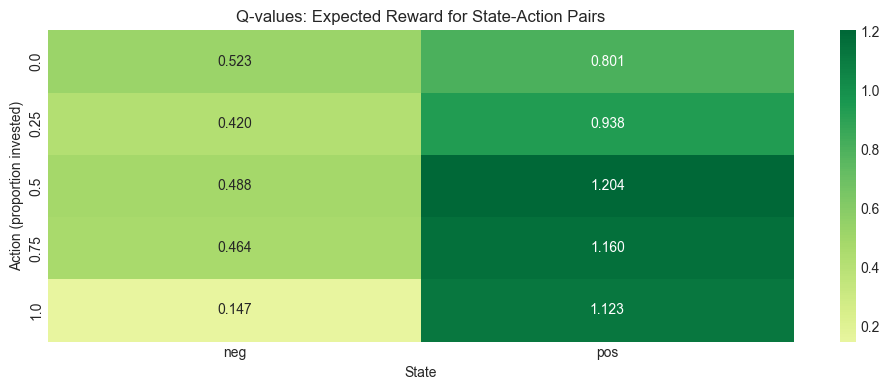

In [19]:
#| label: fig-q_heatmap
#| fig-cap: "Heatmap of Q-values for the simulated AR(1) environment."

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(q_table.T, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax)
ax.set_xlabel('State')
ax.set_ylabel('Action (proportion invested)')
ax.set_title('Q-values: Expected Reward for State-Action Pairs')
plt.tight_layout()
plt.show()

(sec_RLemp2)=
### Q-learning with market data

The second application is based on the financial dataset. To reduce the dimensionality of the problem, we will assume that:  
- only one feature (price-to-book ratio) captures the state of the environment. This feature is processed so that it has only a limited number of possible values;   
- actions take values over a discrete set consisting of three positions: +1 (buy the market), -1 (sell the market) and 0 (hold no risky positions);    
- only two assets are traded: those with fsym_id equal to 3 and 4 - they both have 245 days of trading data.   

The construction of the dataset is coded below.

In [20]:
# Get unique stock IDs to find appropriate assets
stock_counts = data_ml.groupby('fsym_id').size().reset_index(name='count')
print(f"Number of unique stocks: {len(stock_counts)}")
print(f"Stocks with most data points:")
print(stock_counts.nlargest(10, 'count'))

# Select two stocks with sufficient data
# We'll use the first two stocks with the most data points
top_stocks = stock_counts.nlargest(2, 'count')['fsym_id'].values
stock_1, stock_2 = top_stocks[0], top_stocks[1]
print(f"\nSelected stocks: {stock_1}, {stock_2}")

Number of unique stocks: 846
Stocks with most data points:
      fsym_id  count
34   BV3N5V-R    266
47   BZPTB8-R    266
60   CHKL7S-R    266
68   CPCV0Y-R    266
73   CSMTMQ-R    266
79   CYBC69-R    266
84   D1LJ47-R    266
91   D68LVD-R    266
108  DJBQ39-R    266
128  F17SJ1-R    266

Selected stocks: BV3N5V-R, BZPTB8-R


In [21]:
# Extract data for the two selected stocks
data_stock_1 = data_ml[data_ml['fsym_id'] == stock_1].copy()
data_stock_2 = data_ml[data_ml['fsym_id'] == stock_2].copy()

# Get common dates
common_dates = set(data_stock_1['date']).intersection(set(data_stock_2['date']))
data_stock_1 = data_stock_1[data_stock_1['date'].isin(common_dates)].sort_values('date')
data_stock_2 = data_stock_2[data_stock_2['date'].isin(common_dates)].sort_values('date')

print(f"Number of common time points: {len(common_dates)}")

# Extract returns and P/B ratios
return_1 = data_stock_1['R1M'].values
return_2 = data_stock_2['R1M'].values
pb_1 = data_stock_1['PB'].values
pb_2 = data_stock_2['PB'].values

# Random actions for each asset: -1, 0, or 1
n_obs = len(return_1)
action_1 = np.floor(np.random.uniform(0, 1, n_obs) * 3) - 1  # -1, 0, or 1
action_2 = np.floor(np.random.uniform(0, 1, n_obs) * 3) - 1

# Build the RL dataset
RL_data = pd.DataFrame({
    'return_1': return_1,
    'return_2': return_2,
    'pb_1': pb_1,
    'pb_2': pb_2,
    'action_1': action_1.astype(int),
    'action_2': action_2.astype(int)
})

# Unite actions into a single string
RL_data['action'] = RL_data['action_1'].astype(str) + ' ' + RL_data['action_2'].astype(str)

# Simplify states by rounding 5 * P/B ratio
RL_data['pb_1_disc'] = np.round(5 * RL_data['pb_1']).astype(int)
RL_data['pb_2_disc'] = np.round(5 * RL_data['pb_2']).astype(int)

# Unite states into a single string
RL_data['state'] = RL_data['pb_1_disc'].astype(str) + '.' + RL_data['pb_2_disc'].astype(str)

# Compute rewards: portfolio return
RL_data['reward'] = RL_data['action_1'] * RL_data['return_1'] + RL_data['action_2'] * RL_data['return_2']

# Infer next state
RL_data['new_state'] = RL_data['state'].shift(-1)

# Keep only relevant columns and remove last row (no next state)
RL_data = RL_data[['state', 'action', 'reward', 'new_state']].dropna()

print("\nFirst rows of the market data RL dataset:")
RL_data.head()

Number of common time points: 266

First rows of the market data RL dataset:


,state,action,reward,new_state
0,1.4,1 -1,-0.008839,1.4
1,1.4,0 0,0.000000,1.4
2,1.4,0 1,0.187156,1.4
3,1.4,1 0,0.061398,1.4
4,1.4,0 0,0.000000,1.4


Actions and states have to be merged to yield all possible combinations. To simplify the states, we round 5 times the price-to-book ratios. 

We keep the same hyperparameters as in the previous example. Columns below stand for actions: the first (*resp.* second) number notes the position in the first (*resp.* second) asset. The rows correspond to states. The scaled P/B ratios are separated by a point (e.g., "2.3" means that the first (*resp.* second) asset has a scaled P/B of 2 (*resp.* 3).

In [22]:
# Get unique states and actions from the data
states_market = RL_data['state'].unique().tolist()
actions_market = RL_data['action'].unique().tolist()

print(f"Number of unique states: {len(states_market)}")
print(f"Number of unique actions: {len(actions_market)}")
print(f"Total state-action pairs: {len(states_market) * len(actions_market)}")

# Initialize Q-learning agent for market data
agent_market = QLearningAgent(
    states=states_market,
    actions=actions_market,
    alpha=0.1,
    gamma=0.7,
    epsilon=0.1
)

# Train the agent
agent_market.train_on_data(RL_data)

# Display the Q-table
print("\nQ-table (rounded to 3 decimals):")
q_table_market = agent_market.get_q_table().round(3)
print(q_table_market)

print("\nOptimal policy for some states:")
policy = agent_market.get_policy()
for state in list(policy.keys())[:5]:
    print(f"  State {state}: best action = {policy[state]}")

Number of unique states: 18
Number of unique actions: 9
Total state-action pairs: 162

Q-table (rounded to 3 decimals):
      1 -1    0 0    0 1    1 0   -1 1   -1 0  -1 -1    1 1   0 -1
1.4 -0.015  0.010  0.039 -0.015 -0.041  0.034 -0.003  0.042 -0.049
1.5 -0.010  0.000  0.000 -0.004  0.000  0.000  0.000  0.000  0.000
2.4 -0.009  0.021  0.002  0.000 -0.007 -0.057  0.012  0.108 -0.006
3.4  0.003  0.006 -0.010 -0.001  0.000 -0.007  0.040 -0.018 -0.000
1.3 -0.019  0.002  0.018  0.019 -0.016  0.013 -0.010 -0.030 -0.016
1.2  0.000  0.000  0.000 -0.001  0.000  0.004 -0.002  0.000  0.000
1.1  0.004  0.000  0.000  0.000  0.022  0.000  0.000 -0.017  0.024
2.1 -0.002  0.001 -0.006  0.000 -0.007  0.000  0.013 -0.017  0.000
1.0  0.000  0.000  0.000  0.011  0.000  0.019  0.015 -0.017  0.010
0.0 -0.011  0.000  0.000  0.000 -0.021  0.000 -0.092 -0.022  0.000
2.2  0.000  0.000  0.000  0.005  0.000  0.000 -0.048  0.000  0.007
3.2  0.000  0.000  0.000  0.000  0.000 -0.018  0.005  0.029  0.000
3.3 -0.01

The output shows that there are many combinations of states and actions that are not spanned by the data: basically, the $Q$ function has a zero and it is likely that the combination has not been explored. Some states seem to be more often represented, others, less. It is hard to make any sense of the recommendations. Some states are close but the outcomes related to them can be very different. Moreover, there is no coherence and no monotonicity in actions with respect to individual state values: low values of states can be associated to very different actions. 

One reason why these conclusions do not appear trustworthy pertains to the data size. With only 200+ time points and many state-action pairs, this yields on average only a few data points to compute the $Q$ function. This could be improved by testing more random actions, but the limits of the sample size would eventually (rapidly) be reached anyway. This is left as an exercise (see below).

### Visualization of Q-values for Market Data

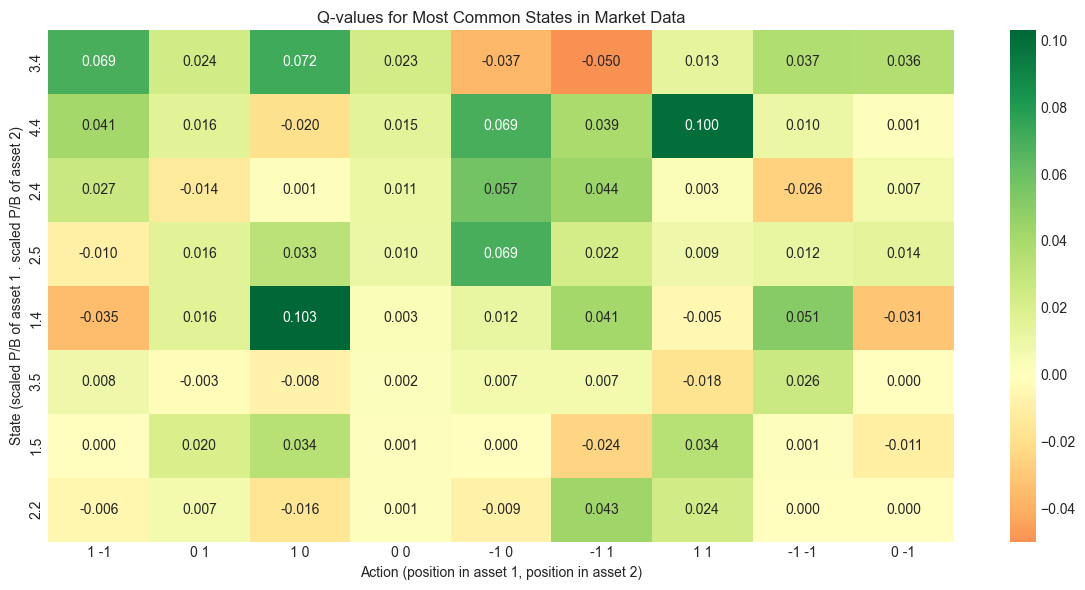

In [23]:
#| label: fig-q_market_heatmap
#| fig-cap: "Heatmap of Q-values for market data environment (truncated for readability)."

# Select most common states for visualization
state_counts = RL_data['state'].value_counts()
top_states = state_counts.head(8).index.tolist()

# Filter Q-table for visualization
q_subset = q_table_market.loc[top_states]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(q_subset, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax)
ax.set_xlabel('Action (position in asset 1, position in asset 2)')
ax.set_ylabel('State (scaled P/B of asset 1 . scaled P/B of asset 2)')
ax.set_title('Q-values for Most Common States in Market Data')
plt.tight_layout()
plt.show()

## Modern RL Approaches: Deep Q-Networks

The tabular Q-learning approach shown above suffers from the curse of dimensionality. Modern approaches use **function approximation** to represent the Q-function, typically with neural networks. This is the foundation of **Deep Q-Networks (DQN)**, which was popularized by DeepMind's work on playing Atari games.

Below, we provide a simple implementation of DQN using Keras for the same simulated environment. Keras 3 supports multiple backends including JAX, TensorFlow, and PyTorch. This demonstrates how neural networks can scale Q-learning to continuous or high-dimensional state spaces.

In [ ]:
class DQNKeras:
        """
        A Deep Q-Network implemented with Keras.
        Compatible with JAX, TensorFlow, or PyTorch backends.
        """
        def __init__(self, state_dim, action_dim, hidden_dim=64, lr=0.001):
            # Build the Q-network
            inputs = keras.Input(shape=(state_dim,))
            x = layers.Dense(hidden_dim, activation='relu')(inputs)
            x = layers.Dense(hidden_dim, activation='relu')(x)
            outputs = layers.Dense(action_dim, activation='linear')(x)
            
            self.model = Model(inputs=inputs, outputs=outputs)
            self.model.compile(
                optimizer=optimizers.Adam(learning_rate=lr),
                loss='mse'
            )
            self.action_dim = action_dim
        
        def predict(self, state):
            """Predict Q-values for a state."""
            state = np.atleast_2d(state)
            return self.model.predict(state, verbose=0)
        
        def update(self, states, targets):
            """Update the network on a batch."""
            return self.model.train_on_batch(states, targets)
    
class DQNAgent:
        """
        Deep Q-Network agent with experience replay using Keras.
        """
        def __init__(self, state_dim, action_dim, lr=0.001, gamma=0.99, epsilon=0.1):
            self.state_dim = state_dim
            self.action_dim = action_dim
            self.gamma = gamma
            self.epsilon = epsilon
            
            self.network = DQNKeras(state_dim, action_dim, hidden_dim=64, lr=lr)
            
            # Experience replay buffer
            self.memory = []
            self.memory_size = 10000
        
        def choose_action(self, state):
            """Choose action using epsilon-greedy policy."""
            if np.random.random() < self.epsilon:
                return np.random.randint(self.action_dim)
            else:
                q_values = self.network.predict(state)
                return np.argmax(q_values[0])
        
        def store_experience(self, state, action, reward, next_state, done):
            """Store experience in replay buffer."""
            if len(self.memory) >= self.memory_size:
                self.memory.pop(0)
            self.memory.append((state, action, reward, next_state, done))
        
        def train(self, batch_size=32):
            """Train the network on a batch from the replay buffer."""
            if len(self.memory) < batch_size:
                return None
            
            # Sample batch
            indices = np.random.choice(len(self.memory), batch_size, replace=False)
            batch = [self.memory[i] for i in indices]
            
            states = np.array([b[0] for b in batch])
            actions = np.array([b[1] for b in batch])
            rewards = np.array([b[2] for b in batch])
            next_states = np.array([b[3] for b in batch])
            dones = np.array([b[4] for b in batch])
            
            # Compute targets using Bellman equation
            current_q = self.network.predict(states)
            next_q = self.network.predict(next_states)
            
            # Q-learning target: r + gamma * max(Q(s', a'))
            targets = current_q.copy()
            for i in range(batch_size):
                if dones[i]:
                    targets[i, actions[i]] = rewards[i]
                else:
                    targets[i, actions[i]] = rewards[i] + self.gamma * np.max(next_q[i])
            
            # Update network
            loss = self.network.update(states, targets)
            return loss
    
print("DQN agent class defined successfully.")

Keras 3.12.0 available with backend: jax
DQN agent class defined successfully.


In [25]:
if KERAS_AVAILABLE:
    # Train DQN on simulated AR(1) environment
    np.random.seed(42)
    
    # State: normalized return (continuous)
    # Actions: 0=0%, 1=25%, 2=50%, 3=75%, 4=100% invested
    action_values = [0.0, 0.25, 0.5, 0.75, 1.0]
    
    agent_dqn = DQNAgent(state_dim=1, action_dim=5, lr=0.001, gamma=0.7, epsilon=0.1)
    
    # Train on simulated data
    n_episodes = 100
    episode_length = 1000
    losses = []
    
    for episode in range(n_episodes):
        # Simulate returns
        returns_episode = simulate_ar1(episode_length, rho, a, sd)
        episode_loss = 0
        n_updates = 0
        
        for t in range(episode_length - 1):
            # State: current return (normalized)
            state = [returns_episode[t] / sd]  # Normalize
            
            # Choose action
            action_idx = agent_dqn.choose_action(state)
            action = action_values[action_idx]
            
            # Compute reward
            reward = returns_episode[t + 1] * action
            
            # Next state
            next_state = [returns_episode[t + 1] / sd]
            done = (t == episode_length - 2)
            
            # Store and train
            agent_dqn.store_experience(state, action_idx, reward, next_state, done)
            loss = agent_dqn.train(batch_size=64)
            if loss is not None:
                episode_loss += loss
                n_updates += 1
        
        avg_loss = episode_loss / max(n_updates, 1)
        losses.append(avg_loss)
        
        if (episode + 1) % 20 == 0:
            print(f"Episode {episode + 1}/{n_episodes}, Avg Loss: {avg_loss:.6f}")
    
    print("\nDQN training complete.")

Episode 20/100, Avg Loss: 0.088640
Episode 40/100, Avg Loss: 0.087876
Episode 60/100, Avg Loss: 0.088382
Episode 80/100, Avg Loss: 0.089057
Episode 100/100, Avg Loss: 0.089003

DQN training complete.


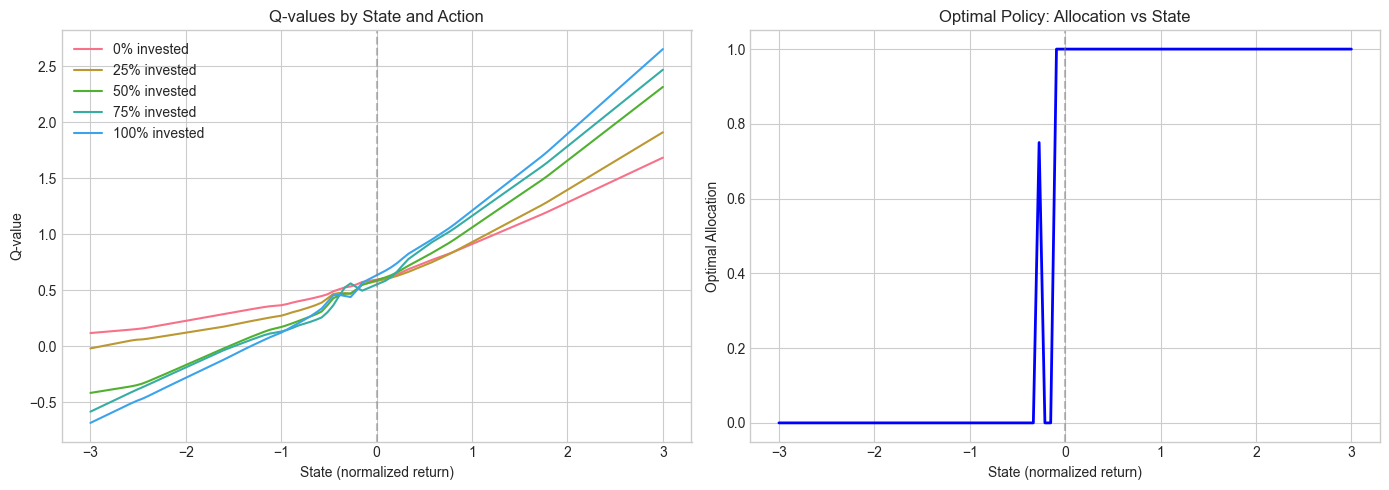

In [26]:
#| label: fig-dqn_policy
#| fig-cap: "Learned policy from DQN: optimal allocation as a function of the state (normalized return)."

if KERAS_AVAILABLE:
    # Visualize the learned policy
    state_range = np.linspace(-3, 3, 100)
    q_values_all = []
    
    for s in state_range:
        q_vals = agent_dqn.network.predict([s]).flatten()
        q_values_all.append(q_vals)
    
    q_values_all = np.array(q_values_all)
    
    # Plot Q-values for each action
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Q-values
    for i, label in enumerate(['0%', '25%', '50%', '75%', '100%']):
        axes[0].plot(state_range, q_values_all[:, i], label=f'{label} invested')
    axes[0].set_xlabel('State (normalized return)')
    axes[0].set_ylabel('Q-value')
    axes[0].set_title('Q-values by State and Action')
    axes[0].legend()
    axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    # Optimal action
    optimal_actions = np.argmax(q_values_all, axis=1)
    optimal_allocations = [action_values[a] for a in optimal_actions]
    
    axes[1].plot(state_range, optimal_allocations, 'b-', linewidth=2)
    axes[1].set_xlabel('State (normalized return)')
    axes[1].set_ylabel('Optimal Allocation')
    axes[1].set_title('Optimal Policy: Allocation vs State')
    axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_ylim(-0.05, 1.05)
    
    plt.tight_layout()
    plt.show()

The DQN learns a policy that is consistent with the tabular Q-learning result: invest more when the previous return is positive (exploiting the positive autocorrelation) and invest less when the previous return is negative. The advantage of DQN is that it can handle continuous states without discretization, and it scales to much higher-dimensional problems.

## Concluding remarks

Reinforcement learning has been applied to financial problems for a long time. Early contributions in the late 1990s include @neuneier1996optimal, @moody1997optimization, @moody1998performance and @neuneier1998enhancing. Since then, many researchers in the computer science field have sought to apply RL techniques to portfolio problems. The advent of massive datasets and the increase in dimensionality make it hard for RL tools to adapt well to very rich environments that are encountered in factor investing. 

Recently, some approaches seek to adapt RL to continuous action spaces (@wang2019continuous, @aboussalah2020continuous) but not to high-dimensional state spaces. These spaces are those required in factor investing because all firms yield hundreds of data points characterizing their economic situation. In addition, applications of RL in financial frameworks have a particularity compared to many typical RL tasks: in financial markets, actions of agents have **no impact on the environment** (unless the agent is able to perform massive trades, which is rare and ill-advised because it pushes prices in the wrong direction). This lack of impact of actions may possibly mitigate the efficiency of traditional RL approaches.

Those are challenges that will need to be solved in order for RL to become competitive with alternative (supervised) methods. Nevertheless, the progressive (online-like) way RL works seems suitable for non-stationary environments: the algorithm slowly shifts paradigms as new data arrives. In stationary environments, it has been shown that RL manages to converge to optimal solutions (@kong2019new, @chaouki2020deep). Therefore, in non-stationary markets, RL could be a recourse to build dynamic predictions that adapt to changing macroeconomic conditions. More research needs to be carried out in this field on large dimensional datasets. 

We end this chapter by underlining that reinforcement learning has also been used to estimate complex theoretical models (@halperin2018market, @garcia2019continuous). The research in the field is incredibly diversified and is orientated towards many directions. It is likely that captivating work will be published in the near future.

## Exercises

1. Test what happens if the process for generating returns has a negative autocorrelation. What is the impact on the $Q$ function and the policy?

2. Keeping the same 2 assets as in {ref}`sec_RLemp2`, increase the size of RL_data by testing **all possible action combinations** for each original data point. Re-run the $Q$-learning function and see what happens. 

3. Implement SARSA (Equation {eq}`eq-SARSAupdate`) and compare its performance with Q-learning on the simulated AR(1) environment.

4. Modify the DQN implementation to use **Double DQN** (separate networks for action selection and value estimation) and compare performance.

5. Implement a simple **policy gradient** method (REINFORCE) for the AR(1) environment using Keras and compare with Q-learning approaches.

## Additional Topics: Stable-Baselines3 Integration

For more sophisticated RL applications, the **Stable-Baselines3** library provides production-ready implementations of various RL algorithms (PPO, SAC, TD3, etc.). Below is an example of how to set up a custom financial environment compatible with the Gymnasium interface.

In [ ]:
class SimplePortfolioEnv(gym.Env):
        """
        A simple portfolio environment for RL.
        
        State: normalized past return
        Action: proportion to invest in risky asset (continuous [0,1])
        Reward: portfolio return
        """
        metadata = {'render_modes': ['human']}
        
        def __init__(self, rho=0.8, a=0.048, sd=0.4, max_steps=252):
            super().__init__()
            
            self.rho = rho
            self.a = a
            self.sd = sd
            self.max_steps = max_steps
            
            # Continuous action space: allocation in [0, 1]
            self.action_space = spaces.Box(low=0, high=1, shape=(1,), dtype=np.float32)
            
            # Observation: normalized return
            self.observation_space = spaces.Box(low=-10, high=10, shape=(1,), dtype=np.float32)
            
            self.reset()
        
        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.current_return = self.a / (1 - self.rho)  # Unconditional mean
            self.step_count = 0
            obs = np.array([self.current_return / self.sd], dtype=np.float32)
            return obs, {}
        
        def step(self, action):
            allocation = float(action[0])
            
            # Generate next return (AR(1))
            epsilon = np.random.normal(0, self.sd)
            next_return = self.a + self.rho * self.current_return + epsilon
            
            # Portfolio return
            reward = allocation * next_return
            
            # Update state
            self.current_return = next_return
            self.step_count += 1
            
            # Check if done
            terminated = self.step_count >= self.max_steps
            truncated = False
            
            obs = np.array([self.current_return / self.sd], dtype=np.float32)
            
            return obs, reward, terminated, truncated, {}
    
# Test the environment
env = SimplePortfolioEnv()
obs, _ = env.reset()
print(f"Initial observation: {obs}")
    
# Take a few random steps
total_reward = 0
for _ in range(10):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated:
            break
    
print(f"After 10 steps, total reward: {total_reward:.4f}")
print("Environment is compatible with Stable-Baselines3!")

Initial observation: [0.6]
After 10 steps, total reward: -0.9202
Environment is compatible with Stable-Baselines3!


This environment can be used with Stable-Baselines3 algorithms:

```python
from stable_baselines3 import PPO, SAC

# Using PPO (Proximal Policy Optimization)
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100000)

# Or using SAC (Soft Actor-Critic) for continuous actions
model = SAC("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100000)
```

These modern algorithms handle continuous action spaces natively and include various improvements over basic Q-learning, such as entropy regularization, importance sampling, and policy clipping.